# Attractor activity on the cycling subnetwork: apoptosis, proliferation or cycling

`00_2_structural_scc_analysis.ipynb` built the **cycling subnetwork**: the nodes that oscillate
inside the cyclic attractors where `Proliferation`, `Autop_digestion` and `Apoptosis` are all free.
Its SCC decomposition gave a 7-node AMPK (`PRKA`)–ULK1–MTOR oscillator that drives a larger
autophagy/apoptosis crosstalk SCC and all three readouts.

This notebook takes **every** attractor of the model, not only the cyclic ones, and asks how the
same subnetwork behaves when the cell ends up in a single phenotype instead:

* **Apoptosis**: `Apoptosis` ON, `Proliferation` and `Autop_digestion` OFF;
* **Proliferation**: `Proliferation` ON, the other two OFF;
* **Cycling**: all three readouts free (the P5 attractors of `00_1` / `00_2`).

Steps:

1. Compute all attractors and group them by their readout pattern.
2. Compute the exact mean activity of every node in every attractor, then average it per group.
3. Rebuild the cycling subnetwork and its SCCs as in `00_2`.
4. Draw the mean activity of each group on the subnetwork.
5. Compare the groups node by node.
6. Find the regulators outside the subnetwork that decide which group the cell lands in.

In [1]:
import io
import os
from pathlib import Path

import biobalm
import biodivine_aeon as ba
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pygraphviz as pgv
import seaborn as sns
from matplotlib.colors import Normalize, to_hex
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

if not Path("model").exists():          # repo root, as in 00_2_structural_scc_analysis.ipynb
    os.chdir("../../../../")
pd.set_option("display.max_colwidth", None)
plt.rcParams["figure.dpi"] = 110

BNET_PATH = Path("model/autophagy_september26/Autophagy_and_apoptosis_Sept26.bnet")
READOUTS = ["Proliferation", "Autop_digestion", "Apoptosis"]

## 1 — All attractors, grouped by readout pattern

`biobalm` finds every attractor of the model. Each one lies in a minimal trap space. As in `00_2`,
the attractor is the set of states reachable from the `biobalm` seed, and AEON computes it
symbolically.

A readout is **ON** or **OFF** when the trap space fixes it, and **free** (`*`) otherwise.
Grouping the attractors by the pattern of the three readouts gives five groups. Three of them are
the ones this notebook studies. The other two are mixed and are kept for the comparison in
section 5.

In [2]:
sd = biobalm.SuccessionDiagram.from_file(str(BNET_PATH))
sd.build()
names = sd.network.variable_names()
INPUTS = [v for v in names if str(sd.network.get_update_function(v)) == v]   # x = x

trap_spaces = sd.minimal_trap_spaces()
seeds = {n: sd.node_attractor_seeds(n, compute=True) for n in trap_spaces}
assert all(len(s) == 1 for s in seeds.values())                      # one attractor per trap space
assert sum(len(sd.node_attractor_seeds(n, compute=True)) for n in sd.node_ids()) == len(trap_spaces)
spaces = {f"A{k + 1}": sd.node_data(n)["space"] for k, n in enumerate(trap_spaces)}
graph = ba.AsynchronousGraph(sd.network)
attractors = {f"A{k + 1}": ba.Reachability.reach_fwd(graph, graph.mk_subspace(seeds[n][0]))
              for k, n in enumerate(trap_spaces)}

GROUP_NAMES = {(0, 0, 1): "Apoptosis", (1, 0, 0): "Proliferation", ("*", "*", "*"): "Cycling",
               (0, "*", "*"): "Autophagy/apoptosis cycling, no proliferation",
               ("*", 0, 1): "Apoptosis, proliferation flickers"}
MAIN = ["Apoptosis", "Proliferation", "Cycling"]

def readout_pattern(space):
    return tuple(space.get(r, "*") for r in READOUTS)

group = pd.Series({k: GROUP_NAMES[readout_pattern(s)] for k, s in spaces.items()}, name="group")
print(f"{len(attractors)} attractors, inputs: {', '.join(INPUTS)}")

88 attractors, inputs: AA_Starvation, Glucose_starv, Growth_factor, Insuline, O_stress, TNF_R_or_DR


In [3]:
group_table = pd.DataFrame({
    g: {**dict(zip(READOUTS, readout_pattern(spaces[keys[0]]))), "attractors": len(keys),
        "free nodes": f"{min(len(names) - len(spaces[k]) for k in keys)}–"
                      f"{max(len(names) - len(spaces[k]) for k in keys)}"}
    for g, keys in group.groupby(group).groups.items()}).T
group_table.loc[MAIN + [g for g in group_table.index if g not in MAIN]]

,Proliferation,Autop_digestion,Apoptosis,attractors,free nodes
Apoptosis,0,0,1,48,2–10
Proliferation,1,0,0,6,0–0
Cycling,*,*,*,4,49–54
"Apoptosis, proliferation flickers",*,0,1,30,10–23


### Which inputs lead to which group

Every input combination has exactly one attractor, so the inputs decide the group alone. `TNF_R_or_DR`
and `Insuline` never change it (checked below), so the table shows the four stress inputs against
`Growth_factor`.

In [5]:
STRESS = ["O_stress", "AA_Starvation", "Glucose_starv"]
inputs = pd.DataFrame(spaces).T[INPUTS].astype(int)
assert not inputs.duplicated().any()                       # one attractor per input combination
assert inputs.assign(group=group).groupby(STRESS + ["Growth_factor"])["group"].nunique().eq(1).all()

def stress_label(row):
    return " + ".join(s for s in STRESS if row[s]) or "no stress"

decision = (inputs.assign(stress=inputs.apply(stress_label, axis=1), group=group)
            .drop_duplicates(["stress", "Growth_factor"])
            .pivot(index="stress", columns="Growth_factor", values="group")
            .rename(columns={0: "Growth_factor OFF", 1: "Growth_factor ON"}))
decision["n stress"] = decision.index.str.count(r"\+") + (decision.index != "no stress")
decision.sort_values(["n stress", "Growth_factor OFF"]).drop(columns="n stress")

AssertionError: 

* **Cycling** is the basal condition: no stress and no growth factor.
* **Proliferation** is the same condition with `Growth_factor` ON. These attractors are fixed points.
* **Apoptosis** is every condition with oxidative stress or amino-acid starvation, plus glucose
  starvation combined with DNA damage, whatever the growth factor. It is the largest group (104
  attractors), and its attractors are **not** fixed points: 7 to 24 nodes stay free inside them.
* The two mixed groups each come from a single stress: DNA damage alone keeps autophagy and apoptosis
  cycling but blocks proliferation; glucose starvation alone fixes apoptosis ON and lets
  proliferation flicker.

## 2 — Mean node activity per attractor and per group

For a node that the trap space fixes, the activity is that value. For a free node, it is the
exact fraction of attractor states in which the node is ON, counted symbolically with AEON. A node
is **cycling** in an attractor when it takes both values there. As in `00_2`, the cycling nodes are
exactly the free nodes of the trap space.

The group profile is the mean over the attractors of the group. Two things to keep in mind:

* a state fraction is not a time average. Under asynchronous updating, the cell does not visit
  every attractor state equally often (see section 4 of `00_1`);
* a group mean of 0.5 can mean "cycling" or "ON in half of the attractors, OFF in the other half".
  The **cycling fraction** (share of the group's attractors in which the node cycles) tells the two
  apart. The network figures below draw a black outline around the nodes that cycle.

This cell takes a few minutes.

In [ ]:
def node_activity(key):
    att, space = attractors[key], spaces[key]
    total = att.cardinality()
    return {v: float(space[v]) if v in space
            else att.intersect(graph.mk_subspace({v: 1})).cardinality() / total for v in names}

activity = pd.DataFrame({k: node_activity(k) for k in attractors}).T
cycling = pd.DataFrame({k: {v: v not in spaces[k] for v in names} for k in attractors}).T

# Free nodes all take both values inside the attractor, so activity is strictly between 0 and 1
assert ((activity > 0) & (activity < 1)).equals(cycling)

group_activity = activity.groupby(group).mean().T[list(GROUP_NAMES.values())]
group_cycling = cycling.groupby(group).mean().T[list(GROUP_NAMES.values())]
group_activity.loc[READOUTS, MAIN]

group,Apoptosis,Proliferation,Cycling
Proliferation,0.0,1.0,0.5
Autop_digestion,0.0,0.0,0.5
Apoptosis,1.0,0.0,0.5


## 3 — The cycling subnetwork and its SCCs

Same construction as `00_2`: the nodes that cycle in at least one of the four **Cycling**
attractors, the signed edges between them, and the SCCs of that subnetwork. The oscillator is the
SCC that contains `PRKA`, the crosstalk SCC is the other non-trivial one, and every remaining node
is feedforward.

To see what decides between the three groups, the figure also needs the regulators **outside** the
subnetwork that act on it. In the Cycling attractors they are all fixed, so they never appear in
`00_2`. They are drawn here as ellipses and called **upstream regulators**.

In [ ]:
def signed_graph(bn):
    g = nx.DiGraph()
    g.add_nodes_from(bn.variable_names())
    for r in bn.regulations():
        g.add_edge(bn.get_variable_name(r["source"]), bn.get_variable_name(r["target"]),
                   sign=str(r["sign"]))
    return g

def nontrivial_sccs(g):
    return sorted((s for s in nx.strongly_connected_components(g)
                   if len(s) > 1 or g.has_edge(*[next(iter(s))] * 2)), key=len)

full = signed_graph(ba.BooleanNetwork.from_file(str(BNET_PATH)).infer_valid_graph())
cycling_keys = group.index[group == "Cycling"]
sub_nodes = [v for v in names if cycling.loc[cycling_keys, v].any()]
sub = full.subgraph(sub_nodes).copy()

oscillator, crosstalk = nontrivial_sccs(sub)
assert "PRKA" in oscillator and len(oscillator) == 7
upstream = sorted({a for a, b in full.edges if a not in sub and b in sub})
entry_edges = [(a, b) for a, b in full.edges if a in upstream and b in sub]

module = {v: "oscillator" if v in oscillator else "crosstalk" if v in crosstalk else "feedforward"
          for v in sub}
module.update({v: "upstream" for v in upstream})
pd.Series(module).value_counts().rename("nodes").to_frame().T

,crosstalk,upstream,feedforward,oscillator
nodes,27,19,18,7


### Drawing

One `dot` layout is used for every panel, so a node is always in the same place. Encoding:

* **node fill**: mean activity in the group, blue = OFF, white = 0.5, red = ON;
* **black outline**: the node cycles inside the attractors of the group. Solid: in every attractor
  of the group; dashed: in some of them. No outline: fixed in every attractor of the group;
* **dashed boxes**: the oscillator and crosstalk SCCs of `00_2`; ellipses are upstream regulators;
  square nodes are readouts;
* **edges**: green arrow = activation, red flat head = inhibition. The edge is faded in
  proportion to the activity of its source: a regulation whose source is OFF has no effect.
  Edges from the subnetwork back to an upstream regulator (for example `Autop_digestion → RRAGA`)
  are drawn too.

In [ ]:
CMAP = sns.color_palette("vlag", as_cmap=True)
DIFF_CMAP = plt.get_cmap("PuOr_r")
MODULE_COLOR = {"oscillator": "#e34948", "crosstalk": "#2a78d6"}
SIGN_COLOR = {"+": "#2f8f4e", "-": "#c0392b"}
drawn = full.subgraph(sub_nodes + upstream).copy()
drawn.remove_edges_from([(a, b) for a, b in drawn.edges if a in upstream and b in upstream])

def network_image(values, cmap, norm, outline, source_activity, title):
    # values: node -> fill value; outline: node -> share of attractors where the node cycles;
    # source_activity: node -> edge strength
    A = pgv.AGraph(directed=True, rankdir="TB", nodesep="0.15", ranksep="0.3", outputorder="edgesfirst",
                   label=title, labelloc="t", fontname="Helvetica-Bold", fontsize="16")
    A.node_attr.update(style="rounded,filled", fontname="Helvetica", fontsize="10",
                       height="0.25", margin="0.06,0.02", penwidth="2.4")
    for v in drawn:          # insertion order is fixed, so dot gives the same layout every time
        rgba = cmap(norm(values[v]))
        light = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2] > 0.55
        A.add_node(v, fillcolor=to_hex(rgba), fontcolor="black" if light else "white",
                   shape="ellipse" if v in upstream else "box",
                   style=("filled" if v in READOUTS + upstream else "rounded,filled")
                         + (",dashed" if 0 < outline[v] < 1 else ""),
                   color="black" if outline[v] > 0 else to_hex(rgba))
    for a, b in drawn.edges:
        strength = source_activity[a]
        alpha = int(255 * (0.12 + 0.88 * strength))
        A.add_edge(a, b, color=SIGN_COLOR[drawn[a][b]["sign"]] + f"{alpha:02x}",
                   penwidth=f"{0.6 + 1.6 * strength:.2f}",
                   arrowhead="normal" if drawn[a][b]["sign"] == "+" else "tee", arrowsize="0.7")
    for name, label in [("oscillator", "oscillator SCC"), ("crosstalk", "crosstalk SCC")]:
        A.add_subgraph([v for v in sub if module[v] == name], name=f"cluster_{name}", label=label,
                       style="dashed", color=MODULE_COLOR[name], fontcolor=MODULE_COLOR[name],
                       fontname="Helvetica-Bold")
    img = plt.imread(io.BytesIO(A.draw(format="png", prog="dot", args="-Gdpi=90")), format="png")
    A.layout(prog="dot")
    return A, img

def show_network(values, cmap, norm, outline, source_activity, title, cbar_label):
    A, img = network_image(values, cmap, norm, outline, source_activity, title)
    fig, ax = plt.subplots(figsize=(img.shape[1] / 90, img.shape[0] / 90 + 0.6))
    ax.imshow(img)
    ax.axis("off")
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.35, pad=0.01,
                 label=cbar_label)
    plt.show()
    return {n: A.get_node(n).attr["pos"] for n in drawn}

## 4 — Mean activity of each group on the subnetwork

### Cycling (all three readouts free)

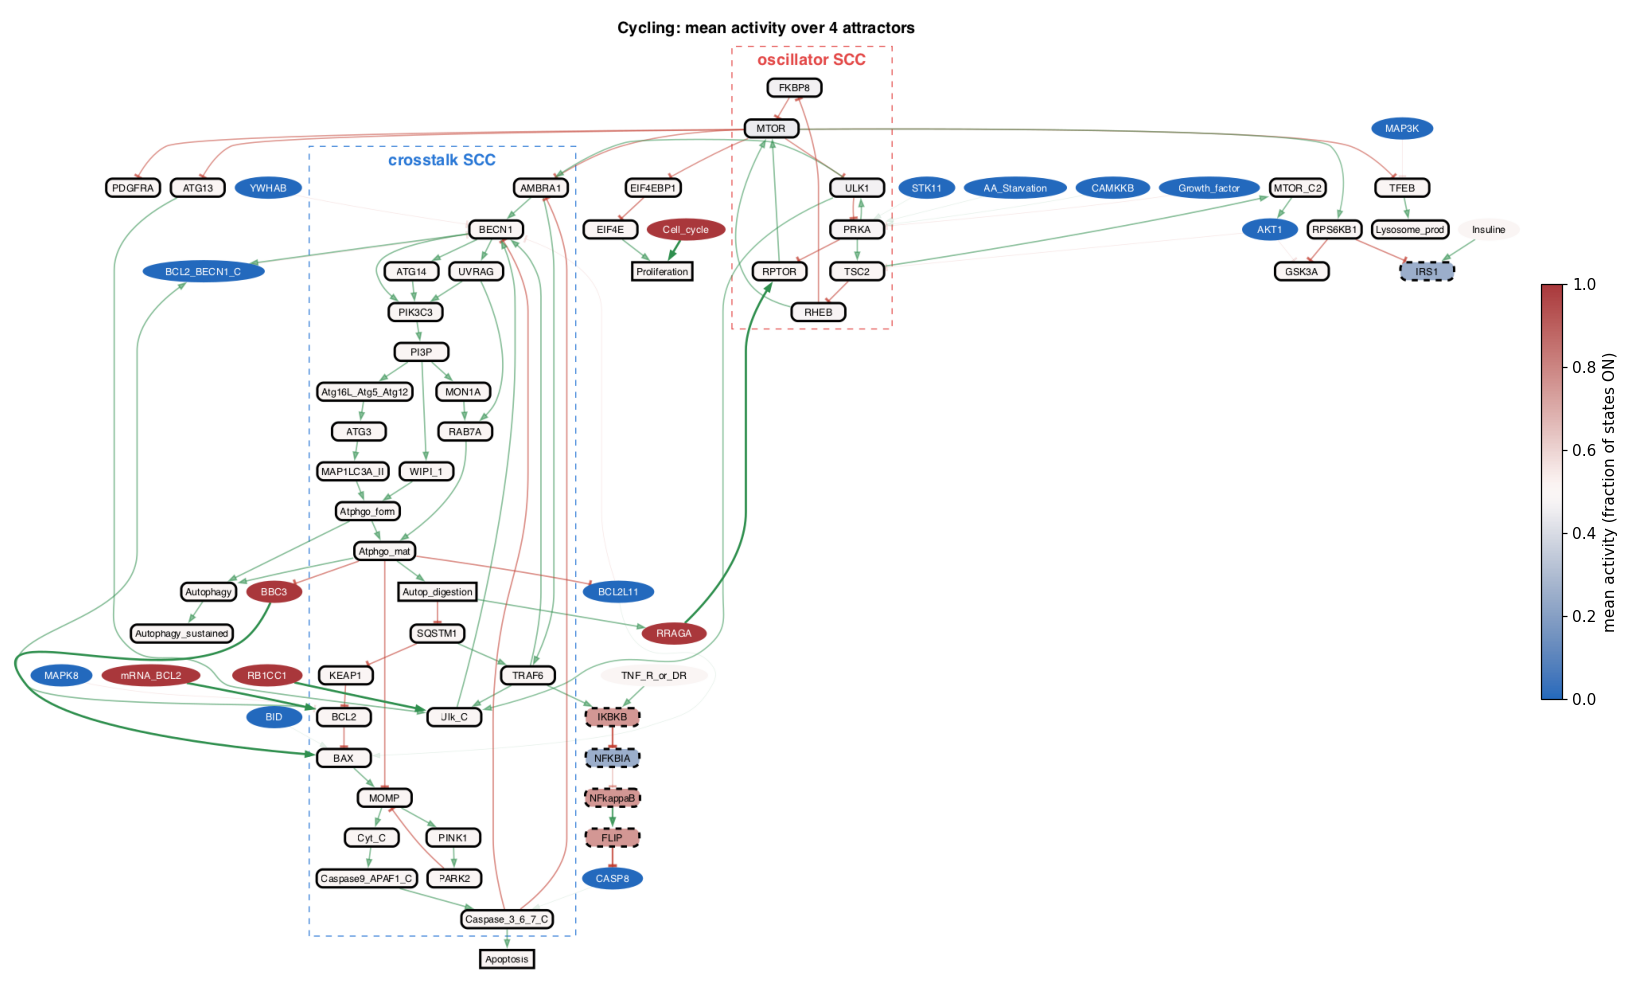

In [ ]:
layouts = {}
def show_group(g):
    n = int((group == g).sum())
    layouts[g] = show_network(group_activity[g], CMAP, Normalize(0, 1), group_cycling[g],
                              group_activity[g],
                              f"{g}: mean activity over {n} attractor{'s' * (n > 1)}",
                              "mean activity (fraction of states ON)")

show_group("Cycling")

With no growth factor and no stress, every upstream regulator is fixed and 47 of the 52
subnetwork nodes cycle in all four attractors. The other five cycle in only some of them: the
TNF/NF-κB branch (`IKBKB`, `NFKBIA`, `NFkappaB`, `FLIP`) when TNF is OFF, and `IRS1` when insulin is ON. All the motion comes from the oscillator: `Growth_factor`
is OFF, so `PRKA`'s rule reduces to `!ULK1`, and `PRKA → ULK1 ⊣ PRKA` closes the negative loop.
The crosstalk SCC and the three readouts follow it (section 6 gives the reduced rules).

### Proliferation only

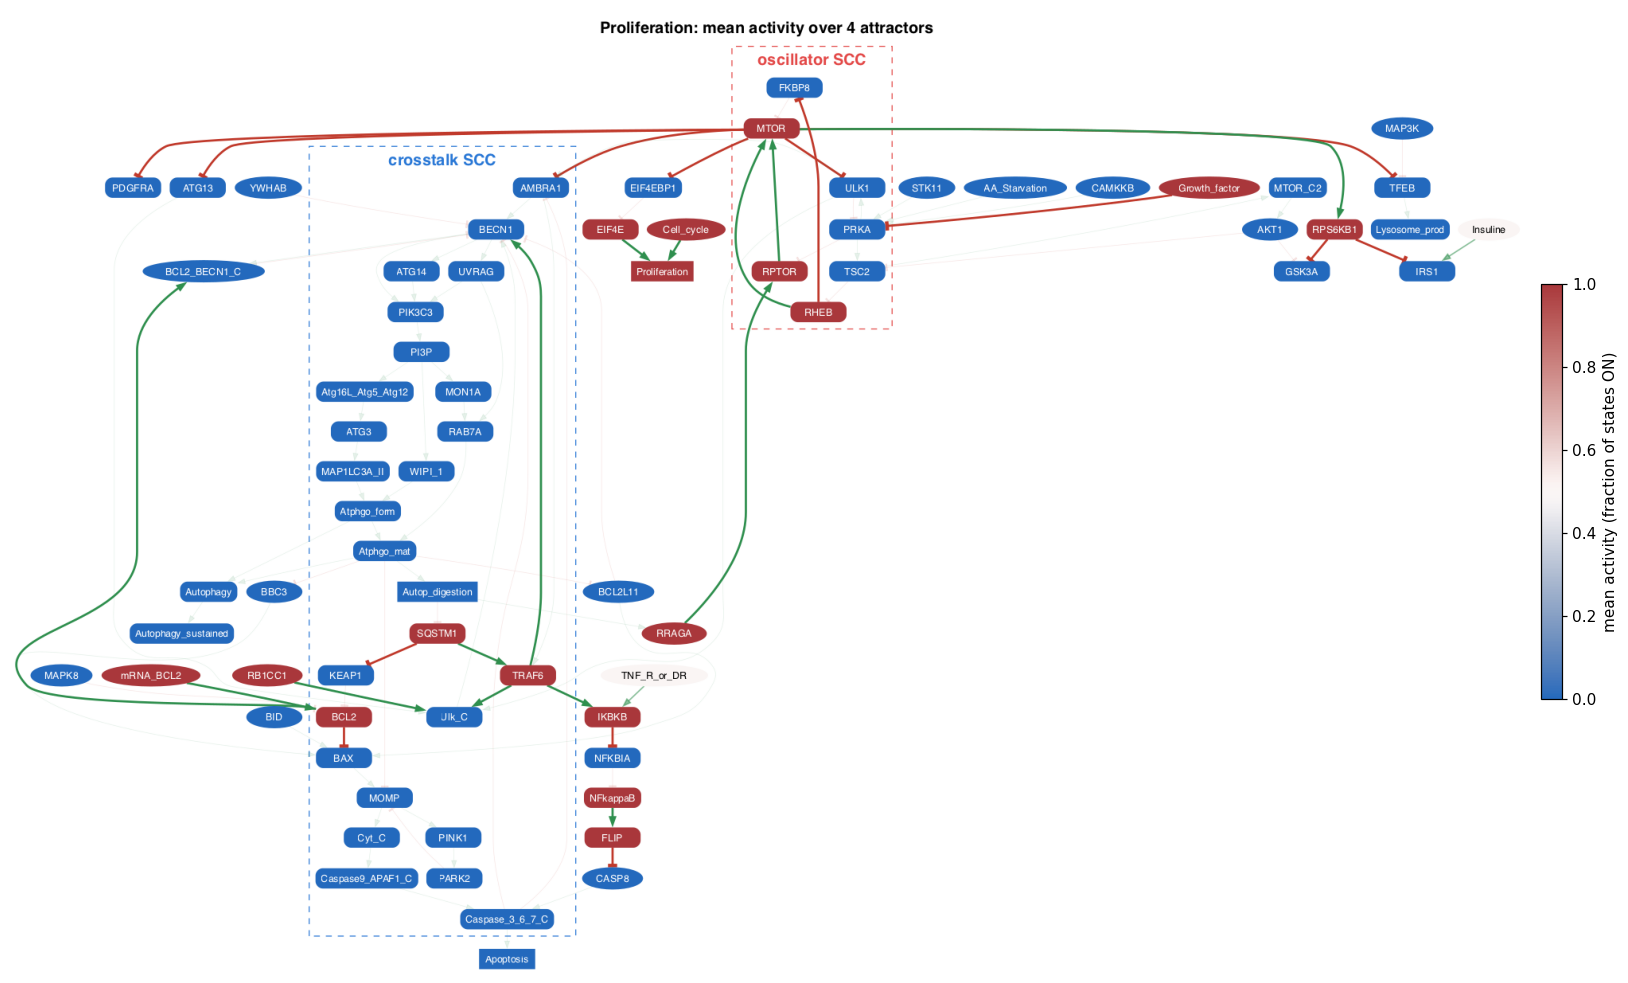

In [ ]:
show_group("Proliferation")

`Growth_factor` ON freezes the whole subnetwork; nothing cycles. `PRKA` is OFF, so the clock stops
at its MTOR-ON phase: `RPTOR`, `RHEB`, `MTOR` ON and `ULK1` OFF. From there, MTOR keeps
`EIF4EBP1` OFF, so `EIF4E` and `Proliferation` stay ON. With `ULK1` OFF, `AMBRA1`, `Ulk_C`
and `BECN1` are OFF and the autophagy cascade is silent. With digestion OFF, `SQSTM1` stays ON and
`KEAP1` OFF, so `BCL2` is ON, `BAX` OFF, and the caspase chain never starts.

### Apoptosis only

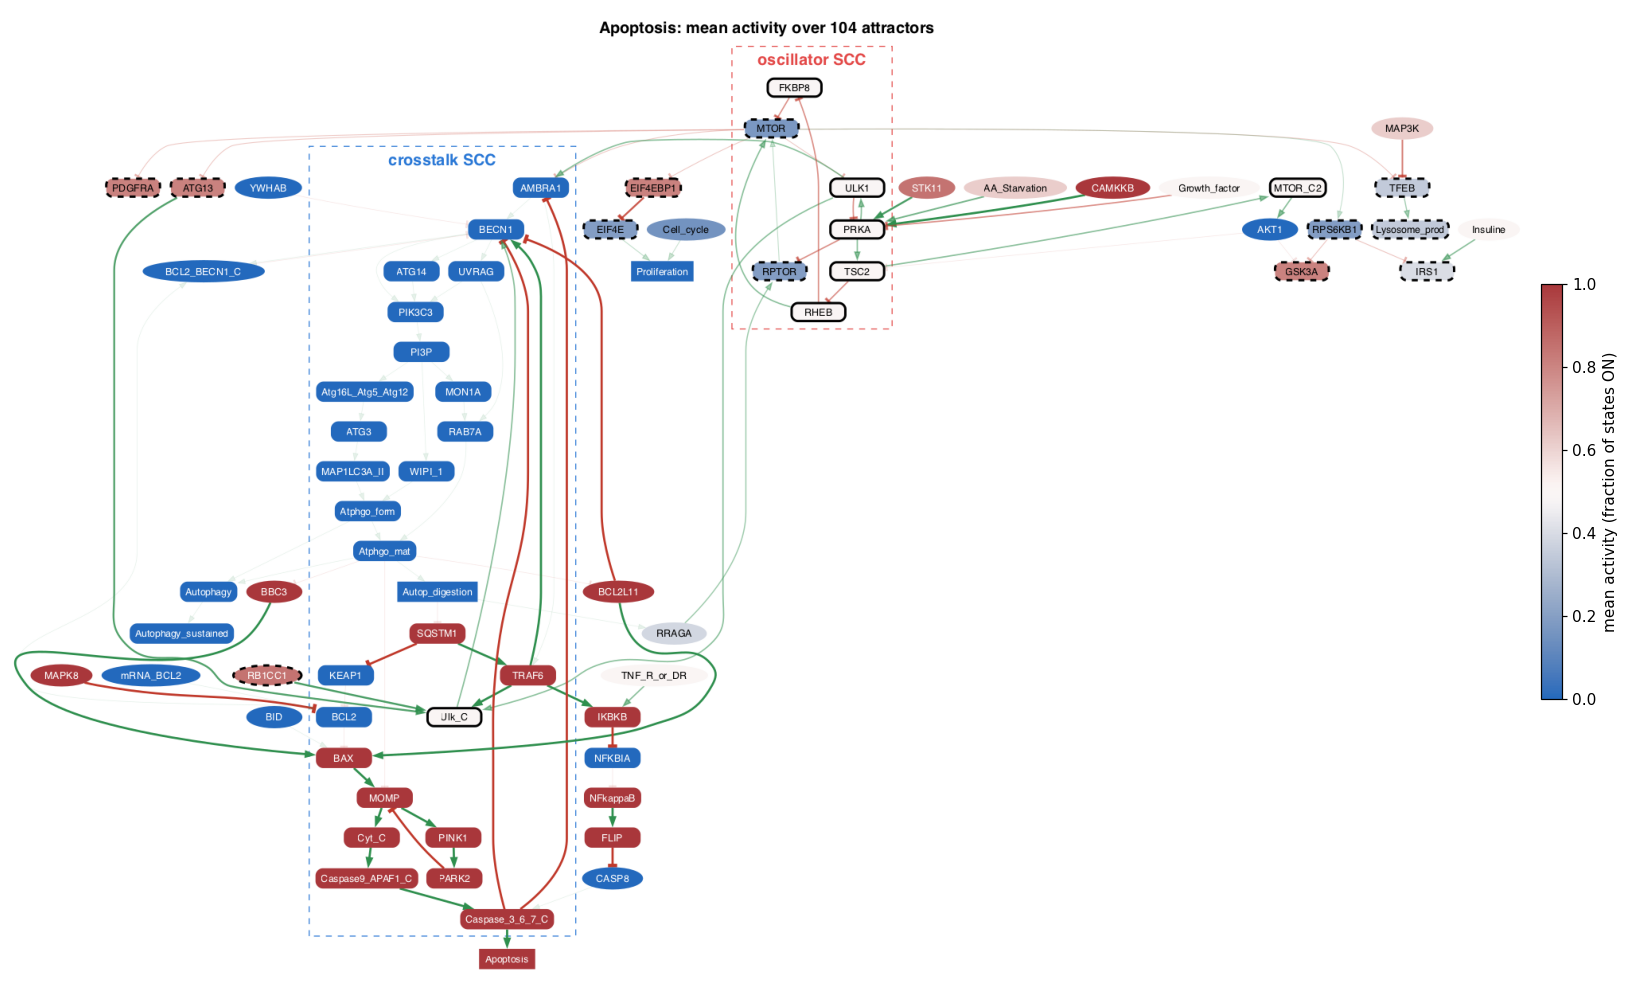

In [ ]:
show_group("Apoptosis")
assert all(l == layouts["Cycling"] for l in layouts.values())   # same layout in every panel

Here the picture is split in two:

* **The oscillator keeps running.** `PRKA`, `ULK1`, `TSC2`, `RHEB` and `FKBP8` cycle in all 104
  attractors. `MTOR` and `RPTOR` cycle only when amino acids are present: under amino-acid
  starvation `RRAGA` (`!AA_Starvation | AA_Starvation & Autop_digestion`) is OFF because digestion
  is OFF, which holds `RPTOR` and `MTOR` OFF.
* **The crosstalk SCC is frozen.** Only `Ulk_C` still cycles. The apoptosis arm is held ON from
  outside the subnetwork: stress turns `MAPK8` ON and `mRNA_BCL2` OFF (`mRNA_BCL2 = !CHOP`), so
  `BCL2` is OFF in every attractor, `BAX` is ON, and with no mature autophagosomes `MOMP` simply
  copies `BAX`. The caspases then cut the clock off from autophagy at two points: `AMBRA1` and
  `BECN1` both require `Caspase_3_6_7_C` OFF, and `BCL2L11` (ON) inhibits `BECN1` as well.
* `Proliferation` is OFF even in attractors where `MTOR` still cycles, because `Cell_cycle` is OFF
  in most of them, and where it is ON, `EIF4E` is OFF.

## 5 — What changes between the groups

### Difference to the Cycling profile

Each panel is (mean activity in the group) − (mean activity in Cycling). Orange: higher in the
group; purple: higher in Cycling. The black outline still marks the nodes that cycle inside the
group. Edges are faded by the source's activity in the group.

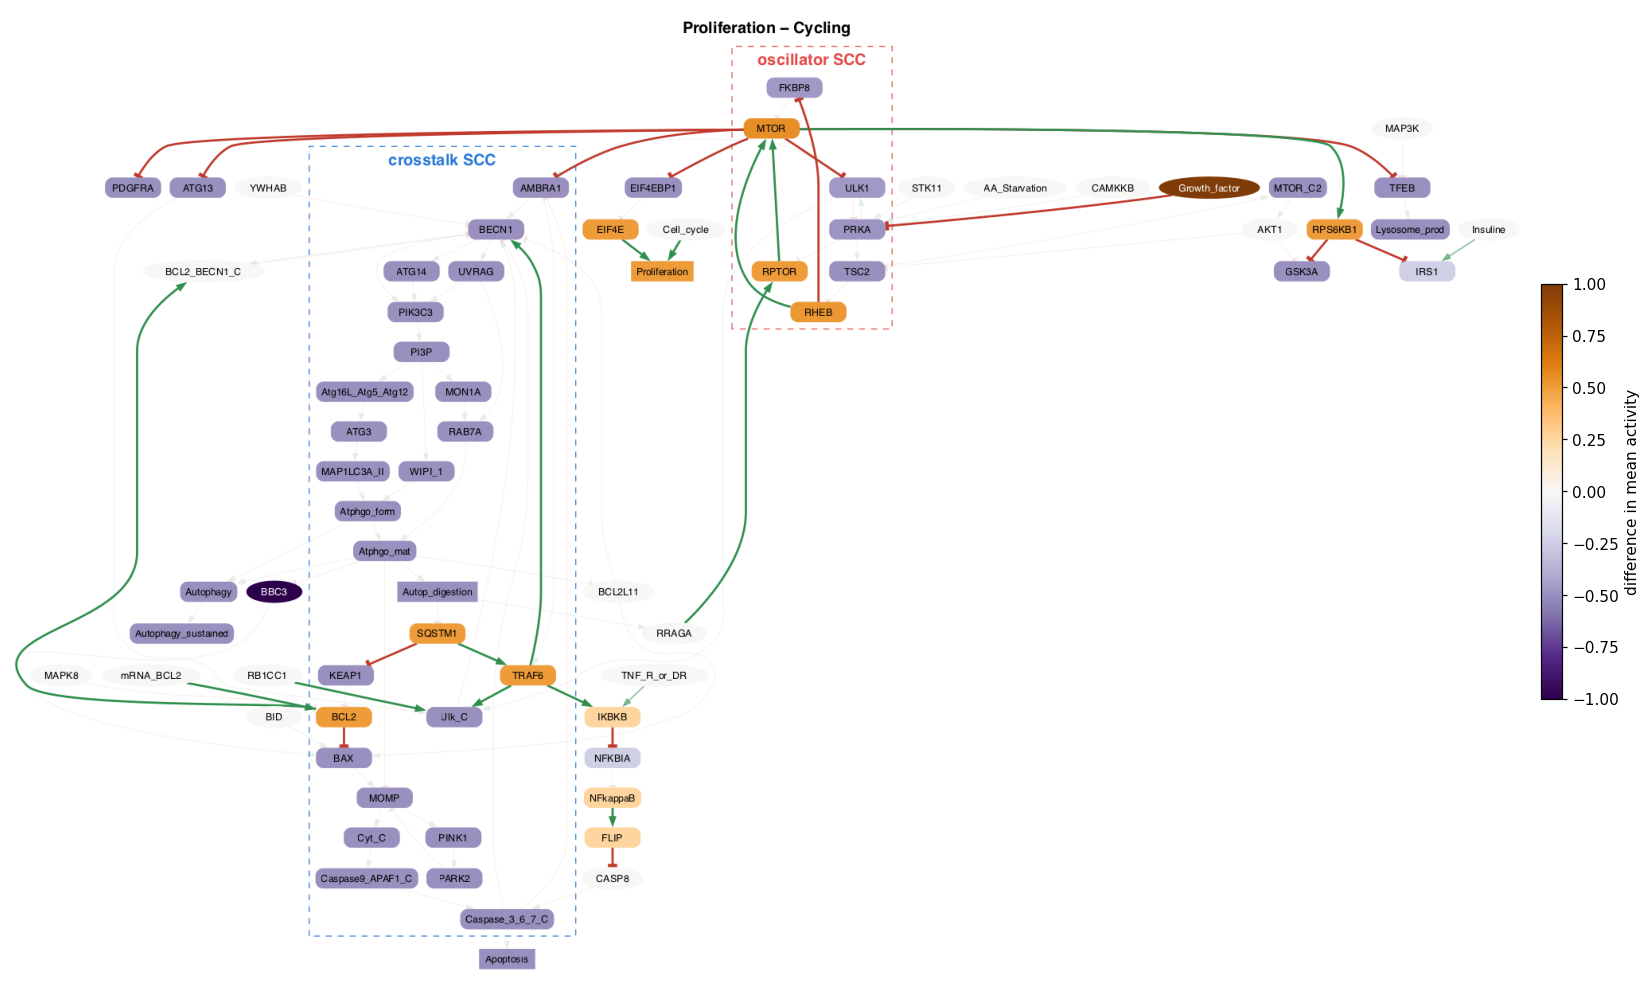

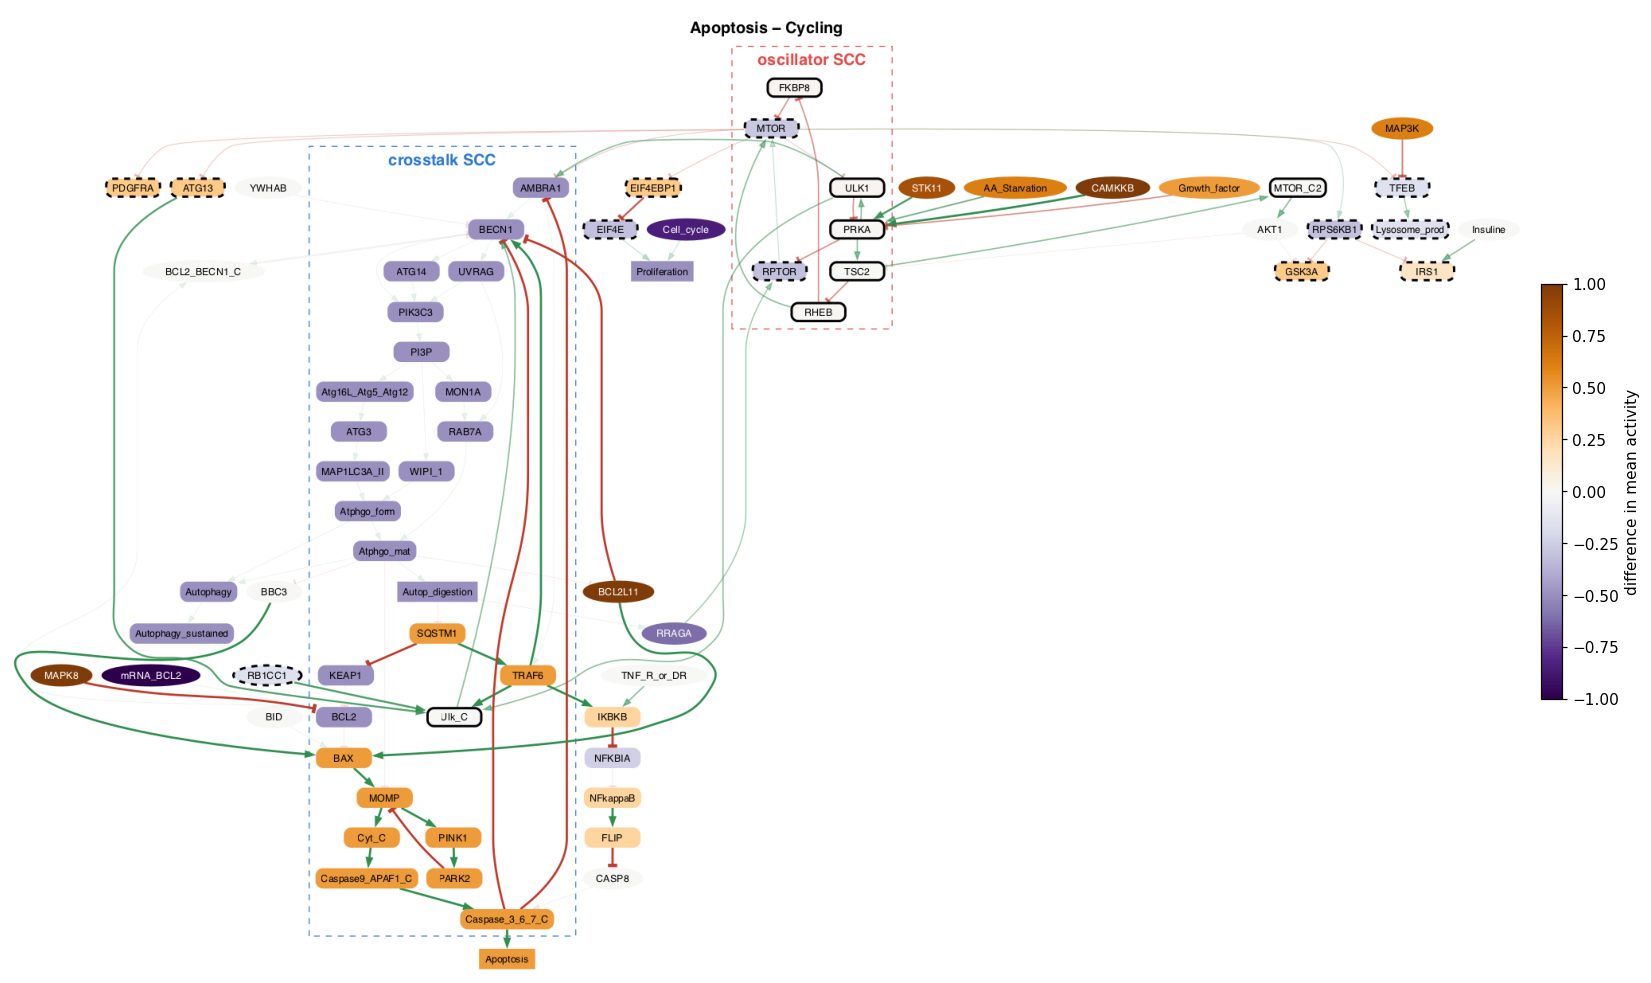

In [11]:
for g in ["Proliferation", "Apoptosis"]:
    diff = group_activity[g] - group_activity["Cycling"]
    show_network(diff, DIFF_CMAP, Normalize(-1, 1), group_cycling[g], group_activity[g],
                 f"{g} − Cycling", "difference in mean activity")

### All five groups, node by node

Rows are the subnetwork nodes ordered by module (and the upstream regulators), columns are the
five groups. The number is the mean activity. A **`~`** marks a node that cycles in at least
one attractor of the group.

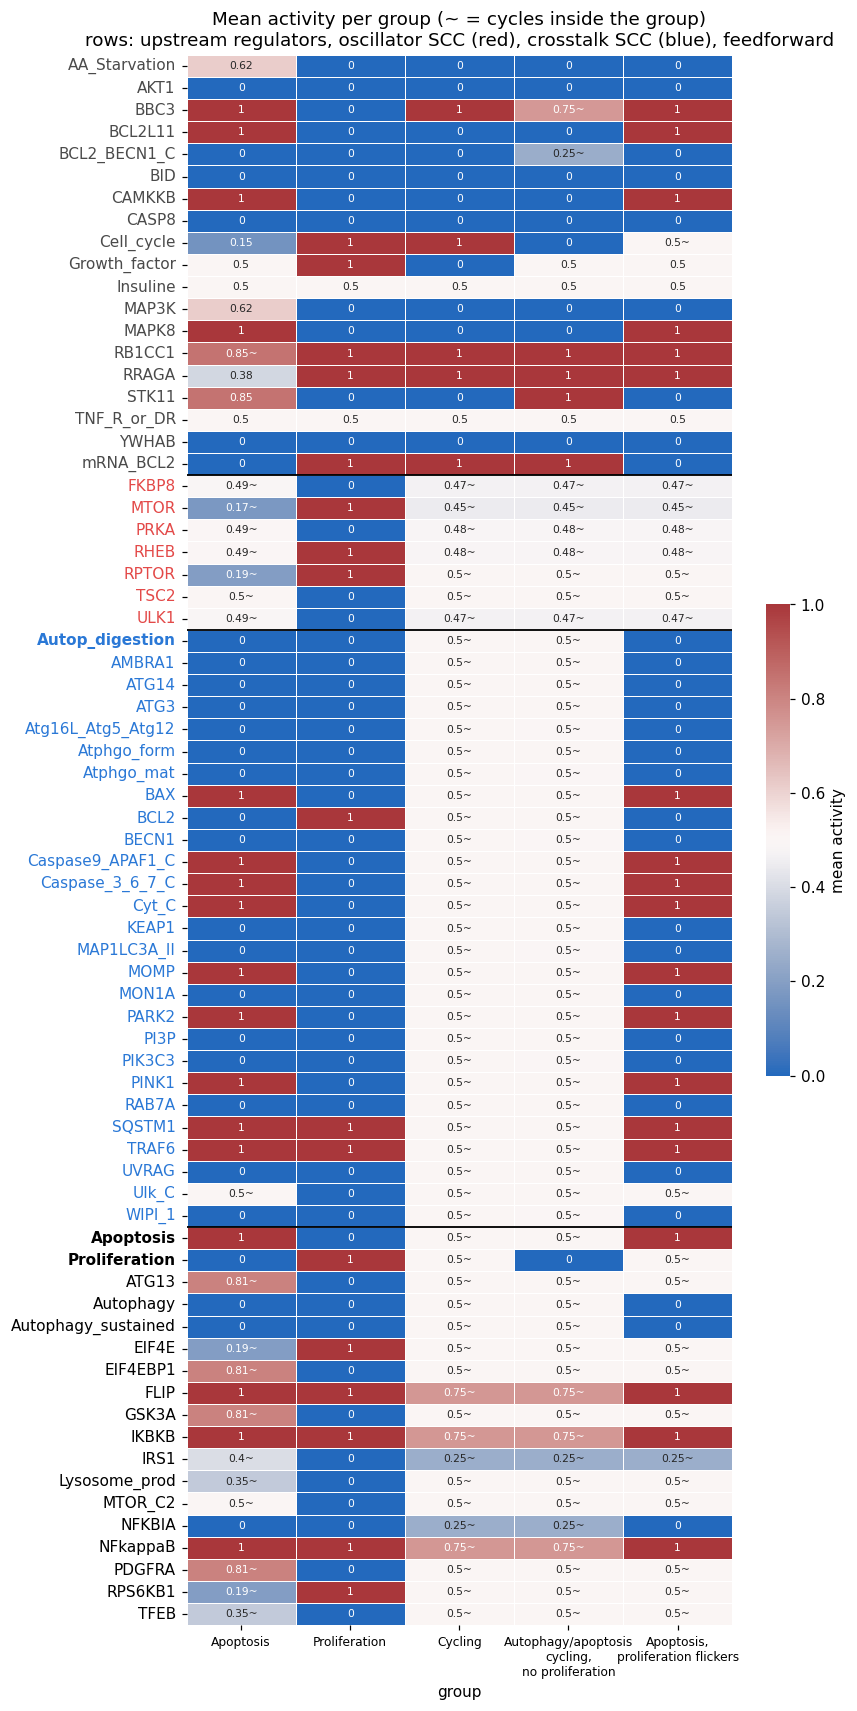

In [12]:
MODULE_ORDER = ["upstream", "oscillator", "crosstalk", "feedforward"]
rows = sorted(drawn, key=lambda v: (MODULE_ORDER.index(module[v]), v not in READOUTS, v))
cols = list(GROUP_NAMES.values())
annot = group_activity.loc[rows, cols].map(lambda x: f"{x:.2f}".rstrip("0").rstrip(".")) \
        + np.where(group_cycling.loc[rows, cols] > 0, "~", "")

fig, ax = plt.subplots(figsize=(8, 0.24 * len(rows) + 1.5))
sns.heatmap(group_activity.loc[rows, cols], cmap=CMAP, vmin=0, vmax=1, annot=annot, fmt="",
            annot_kws={"fontsize": 7}, linewidths=0.4, linecolor="white",
            cbar_kws={"label": "mean activity", "shrink": 0.3}, ax=ax)
ax.set_xticklabels([c.replace(", ", ",\n").replace(" cycling", "\ncycling") for c in cols],
                   rotation=0, fontsize=8)
ax.set_ylabel("")
for i, v in enumerate(rows):
    if i and module[v] != module[rows[i - 1]]:
        ax.axhline(i, color="black", lw=1.2)
for lab in ax.get_yticklabels():
    lab.set_color(MODULE_COLOR.get(module[lab.get_text()], "#4a4a4a" if module[lab.get_text()] == "upstream" else "black"))
    lab.set_fontweight("bold" if lab.get_text() in READOUTS else "normal")
ax.set_title("Mean activity per group (~ = cycles inside the group)\n"
             "rows: upstream regulators, oscillator SCC (red), crosstalk SCC (blue), feedforward")
plt.show()

### Which subnetwork nodes stop cycling

For each of the three main groups: the subnetwork nodes that cycle in **every** attractor of the
group, and the ones frozen ON or OFF in every attractor.

In [13]:
def freeze_table(g):
    keys = group.index[group == g]
    a, c = activity.loc[keys, sub_nodes], cycling.loc[keys, sub_nodes]
    return {"cycling in all": sorted(c.columns[c.all()]),
            "frozen ON": sorted(a.columns[(a == 1).all()]),
            "frozen OFF": sorted(a.columns[(a == 0).all()]),
            "depends on attractor": sorted(c.columns[~c.all() & ~(a == 1).all() & ~(a == 0).all()])}

freeze = {g: freeze_table(g) for g in MAIN}
pd.DataFrame({g: {k: f"({len(v)}) " + ", ".join(v) for k, v in t.items()} for g, t in freeze.items()})

,Apoptosis,Proliferation,Cycling
cycling in all,"(7) FKBP8, MTOR_C2, PRKA, RHEB, TSC2, ULK1, Ulk_C",(0),"(47) AMBRA1, ATG13, ATG14, ATG3, Apoptosis, Atg16L_Atg5_Atg12, Atphgo_form, Atphgo_mat, Autop_digestion, Autophagy, Autophagy_sustained, BAX, BCL2, BECN1, Caspase9_APAF1_C, Caspase_3_6_7_C, Cyt_C, EIF4E, EIF4EBP1, FKBP8, GSK3A, KEAP1, Lysosome_prod, MAP1LC3A_II, MOMP, MON1A, MTOR, MTOR_C2, PARK2, PDGFRA, PI3P, PIK3C3, PINK1, PRKA, Proliferation, RAB7A, RHEB, RPS6KB1, RPTOR, SQSTM1, TFEB, TRAF6, TSC2, ULK1, UVRAG, Ulk_C, WIPI_1"
frozen ON,"(13) Apoptosis, BAX, Caspase9_APAF1_C, Caspase_3_6_7_C, Cyt_C, FLIP, IKBKB, MOMP, NFkappaB, PARK2, PINK1, SQSTM1, TRAF6","(12) BCL2, EIF4E, FLIP, IKBKB, MTOR, NFkappaB, Proliferation, RHEB, RPS6KB1, RPTOR, SQSTM1, TRAF6",(0)
frozen OFF,"(21) AMBRA1, ATG14, ATG3, Atg16L_Atg5_Atg12, Atphgo_form, Atphgo_mat, Autop_digestion, Autophagy, Autophagy_sustained, BCL2, BECN1, KEAP1, MAP1LC3A_II, MON1A, NFKBIA, PI3P, PIK3C3, Proliferation, RAB7A, UVRAG, WIPI_1","(40) AMBRA1, ATG13, ATG14, ATG3, Apoptosis, Atg16L_Atg5_Atg12, Atphgo_form, Atphgo_mat, Autop_digestion, Autophagy, Autophagy_sustained, BAX, BECN1, Caspase9_APAF1_C, Caspase_3_6_7_C, Cyt_C, EIF4EBP1, FKBP8, GSK3A, IRS1, KEAP1, Lysosome_prod, MAP1LC3A_II, MOMP, MON1A, MTOR_C2, NFKBIA, PARK2, PDGFRA, PI3P, PIK3C3, PINK1, PRKA, RAB7A, TFEB, TSC2, ULK1, UVRAG, Ulk_C, WIPI_1",(0)
depends on attractor,"(11) ATG13, EIF4E, EIF4EBP1, GSK3A, IRS1, Lysosome_prod, MTOR, PDGFRA, RPS6KB1, RPTOR, TFEB",(0),"(5) FLIP, IKBKB, IRS1, NFKBIA, NFkappaB"


In [14]:
# Module-level view: how many nodes of each module cycle in all attractors of the group
pd.DataFrame({g: {m: f"{sum(module[v] == m for v in freeze[g]['cycling in all'])}/"
                     f"{sum(module[v] == m for v in sub)}"
                  for m in ["oscillator", "crosstalk", "feedforward"]}
              for g in MAIN}).rename_axis("nodes cycling in every attractor")

,Apoptosis,Proliferation,Cycling
nodes cycling in every attractor,,,
oscillator,5/7,0/7,7/7
crosstalk,1/27,0/27,27/27
feedforward,1/18,0/18,13/18


## 6 — The decision: upstream regulators acting on the subnetwork

Every edge that enters the subnetwork from outside, with the mean value of its source in each
group. Inside the Cycling attractors these sources are all fixed, which is why `00_2` could cut them.
They are what changes between the groups.

In [15]:
entry = pd.DataFrame([{"edge": f"{a} {'→' if full[a][b]['sign'] == '+' else '⊣'} {b}",
                       "target module": module[b], **group_activity.loc[a, MAIN].round(2)}
                      for a, b in entry_edges])
entry["changes"] = entry[MAIN].nunique(axis=1) > 1
entry.sort_values(["changes", "target module"], ascending=[False, True], ignore_index=True)

,edge,target module,Apoptosis,Proliferation,Cycling,changes
0,BBC3 → BAX,crosstalk,1.00,0.0,1.0,True
1,BCL2L11 → BAX,crosstalk,1.00,0.0,0.0,True
2,BCL2L11 ⊣ BECN1,crosstalk,1.00,0.0,0.0,True
3,MAPK8 ⊣ BCL2,crosstalk,1.00,0.0,0.0,True
4,RB1CC1 → Ulk_C,crosstalk,0.85,1.0,1.0,True
5,mRNA_BCL2 → BCL2,crosstalk,0.00,1.0,1.0,True
6,Cell_cycle → Proliferation,feedforward,0.15,1.0,1.0,True
7,MAP3K ⊣ TFEB,feedforward,0.62,0.0,0.0,True
8,AA_Starvation → PRKA,oscillator,0.62,0.0,0.0,True
9,CAMKKB → PRKA,oscillator,1.00,0.0,0.0,True


### Effective rules of the decision nodes in each group

To see *how* those upstream values act, fix every node that has the same value in all attractors of
a group, propagate the constants through the rules (AEON `inline_constants`, as in `00_2`), and
read the rule that is left for each key node. A number means the node is frozen at that value in the
whole group.

In [16]:
KEY = ["PRKA", "ULK1", "MTOR", "RPTOR", "BCL2", "BAX", "MOMP", "BECN1", "Caspase_3_6_7_C",
       "EIF4E", "Proliferation"]

def effective_rules(g):
    keys = group.index[group == g]
    a = activity.loc[keys]
    constants = {v: int(a[v].iloc[0]) for v in names if a[v].isin([0, 1]).all() and a[v].nunique() == 1}
    bn = ba.BooleanNetwork.from_file(str(BNET_PATH))
    for v, value in constants.items():
        bn.set_update_function(v, "true" if value else "false")
    bn = bn.inline_constants(infer_constants=True, repair_graph=True)
    left = bn.variable_names()
    return {v: str(bn.get_update_function(v)) if v in left else str(constants[v]) for v in KEY}

effective = pd.DataFrame({"full rule": {v: str(sd.network.get_update_function(v)) for v in KEY},
                          **{g: effective_rules(g) for g in MAIN}})
effective

,full rule,Apoptosis,Proliferation,Cycling
PRKA,(!Growth_factor & !ULK1) | (Growth_factor & !AA_Starvation & !STK11 & !ULK1 & CAMKKB) | (Growth_factor & !AA_Starvation & STK11 & !ULK1) | (Growth_factor & AA_Starvation & !ULK1),!ULK1,0,!ULK1
ULK1,!MTOR & PRKA,!MTOR & PRKA,0,!MTOR & PRKA
MTOR,RPTOR & RHEB & !FKBP8,RPTOR & RHEB & !FKBP8,1,RPTOR & RHEB & !FKBP8
RPTOR,!PRKA & RRAGA,!PRKA & RRAGA,1,!PRKA
BCL2,!KEAP1 & !MAPK8 & mRNA_BCL2,0,1,!KEAP1
BAX,(!BBC3 & !BCL2L11 & !BCL2 & BID) | (!BBC3 & BCL2L11 & !BCL2) | (BBC3 & !BCL2),1,0,!BCL2
MOMP,(!Atphgo_mat & BAX) | (Atphgo_mat & BAX & !PARK2),1,0,(!Atphgo_mat & BAX) | (Atphgo_mat & BAX & !PARK2)
BECN1,Ulk_C & AMBRA1 & !BCL2_BECN1_C & TRAF6 & !Caspase_3_6_7_C & !BCL2L11 & !YWHAB,0,0,Ulk_C & AMBRA1 & TRAF6 & !Caspase_3_6_7_C
Caspase_3_6_7_C,(!Caspase9_APAF1_C & CASP8) | Caspase9_APAF1_C,1,0,Caspase9_APAF1_C
EIF4E,!EIF4EBP1,!EIF4EBP1,1,!EIF4EBP1


In the Cycling group `MAPK8` is OFF and `mRNA_BCL2` ON, so `BCL2 = !KEAP1` and `BAX = !BCL2`. The
apoptosis arm is therefore not driven by the clock through the MAPK8 route. It follows the
autophagy flux: `Autop_digestion ⊣ SQSTM1 ⊣ KEAP1 ⊣ BCL2 ⊣ BAX → MOMP`. Digestion degrades p62,
which releases KEAP1, which removes BCL2 and lets BAX permeabilise the mitochondria. The caspases
then shut `BECN1` down again (`!Caspase_3_6_7_C`), and the crosstalk loop closes. In the two
single-phenotype groups both ends of that loop are fixed from outside, so it cannot turn.

## Summary

* All 128 attractors fall into five readout groups, and the inputs alone decide the group. TNF and
  insulin never matter:
  * **Cycling** — no stress, no growth factor (4 attractors);
  * **Proliferation** — no stress, growth factor ON (4 fixed points);
  * **Apoptosis** — oxidative stress, amino-acid starvation, or glucose starvation together with DNA
    damage (104 attractors).
* **Cycling.** The whole subnetwork moves. The free-running AMPK–ULK1–MTOR oscillator
  (`PRKA = !ULK1`) drives proliferation through MTOR and autophagy through ULK1/AMBRA1/BECN1.
  Apoptosis follows the autophagy flux through `SQSTM1 ⊣ KEAP1 ⊣ BCL2 ⊣ BAX`, and caspases feed
  back on `BECN1`.
* **Proliferation.** Growth factor makes `PRKA`'s rule false. The oscillator stops at
  MTOR ON / ULK1 OFF. That one stop explains the whole phenotype: MTOR → EIF4E → Proliferation
  ON, ULK1 OFF → no autophagy, and no digestion → p62 ON → KEAP1 OFF → BCL2 ON → no MOMP.
* **Apoptosis.** The oscillator is still running, but the stress inputs fix the crosstalk SCC from
  outside: `MAPK8` ON and `mRNA_BCL2` OFF remove BCL2, BAX and MOMP are locked ON, and the active
  caspases block `AMBRA1` and `BECN1`. The clock keeps cycling, but it is disconnected from every
  readout.
* So the three outcomes are three states of the same two modules. *Proliferation*: the
  oscillator is stopped. *Apoptosis*: the oscillator runs, but the crosstalk SCC is clamped.
  *Cycling*: both are free.
* Caveat: activities are exact fractions of attractor states, not time averages. Use MaBoSS or the
  random walk of `00_1` (section 4) for occupancy times.